In [7]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

In [8]:
# Paste your dataset path here (same as before)
DATASET_PATH = Path(r"C:\Users\jessi\OneDrive\Desktop\aiims2")

# Choose your output size — pick one
IMAGE_SIZE = (256, 256)   # use this, or change to (384, 384)

LABELS = ['benign', 'malignant', 'normal']

# Where to save processed files
OUTPUT_PATH = DATASET_PATH / 'processed'
OUTPUT_PATH.mkdir(exist_ok=True)

print(f"Output folder: {OUTPUT_PATH}")
print(f"Target size: {IMAGE_SIZE}")

Output folder: C:\Users\jessi\OneDrive\Desktop\aiims2\processed
Target size: (256, 256)


In [9]:
# Grab the very first image to test pipeline before running on everything
label = 'benign'
folder = DATASET_PATH / label
images = sorted([f for f in folder.glob("*.png") if '_mask' not in f.name])
test_img_path = images[0]
test_mask_path = folder / (test_img_path.stem + '_mask.png')

print(f"Testing on: {test_img_path.name}")

# Load
img  = np.array(Image.open(test_img_path).convert('L'))   # grayscale
mask = np.array(Image.open(test_mask_path).convert('L'))

print(f"Original image shape: {img.shape}")
print(f"Original mask shape:  {mask.shape}")
print(f"Image dtype: {img.dtype}, min: {img.min()}, max: {img.max()}")

Testing on: benign (1).png
Original image shape: (471, 562)
Original mask shape:  (471, 562)
Image dtype: uint8, min: 0, max: 255


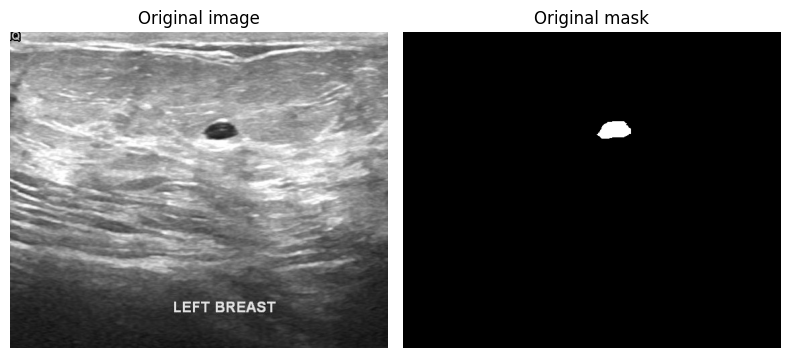

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original image')
axes[0].axis('off')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Original mask')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [11]:
def preprocess_image_and_mask(img_path, mask_path, target_size=(256, 256)):
    """
    Loads one image+mask pair and applies:
    - Grayscale conversion
    - Resize image with bilinear interpolation
    - Resize mask with nearest-neighbor (preserves binary values)
    - Normalize image: (image - mean) / std
    - Binarize mask: 0 or 1
    """
    # --- Load ---
    img  = Image.open(img_path).convert('L')    # grayscale PIL
    mask = Image.open(mask_path).convert('L')   # grayscale PIL

    # --- Resize ---
    img_resized  = img.resize(target_size, Image.BILINEAR)         # smooth resize for image
    mask_resized = mask.resize(target_size, Image.NEAREST)         # nearest-neighbor for mask

    # --- Convert to numpy ---
    img_arr  = np.array(img_resized, dtype=np.float32)
    mask_arr = np.array(mask_resized, dtype=np.uint8)

    # --- Normalize image: (image - mean) / std ---
    mean = img_arr.mean()
    std  = img_arr.std()
    if std > 0:
        img_normalized = (img_arr - mean) / std
    else:
        img_normalized = img_arr - mean   # edge case: flat image

    # --- Binarize mask: convert 0-255 to 0-1 ---
    mask_binary = (mask_arr > 127).astype(np.uint8)

    return img_normalized, mask_binary, mean, std

Processed image shape: (256, 256)
Processed mask shape:  (256, 256)
Image mean (before norm): 132.37, std: 57.48
Normalized image — mean: 0.0000, std: 1.0000
Mask unique values: [0 1]


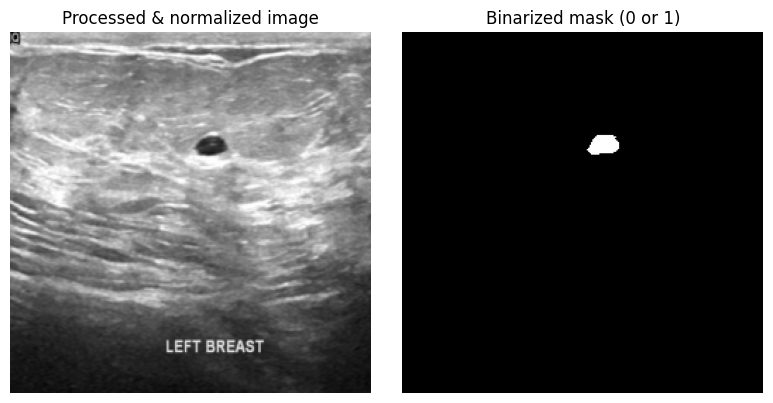

In [12]:
img_proc, mask_proc, orig_mean, orig_std = preprocess_image_and_mask(
    test_img_path, test_mask_path, IMAGE_SIZE
)

print(f"Processed image shape: {img_proc.shape}")
print(f"Processed mask shape:  {mask_proc.shape}")
print(f"Image mean (before norm): {orig_mean:.2f}, std: {orig_std:.2f}")
print(f"Normalized image — mean: {img_proc.mean():.4f}, std: {img_proc.std():.4f}")
print(f"Mask unique values: {np.unique(mask_proc)}")   # should be [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_proc, cmap='gray')
axes[0].set_title('Processed & normalized image')
axes[0].axis('off')
axes[1].imshow(mask_proc, cmap='gray')
axes[1].set_title('Binarized mask (0 or 1)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [13]:
records = []
errors  = []

for label in LABELS:
    folder = DATASET_PATH / label
    images = sorted([f for f in folder.glob("*.png") if '_mask' not in f.name])
    
    print(f"\nProcessing {label}: {len(images)} images...")
    
    for img_path in images:
        mask_path = folder / (img_path.stem + '_mask.png')
        
        if not mask_path.exists():
            print(f"  WARNING: mask missing for {img_path.name}")
            errors.append(img_path.name)
            continue
        
        try:
            img_proc, mask_proc, mean, std = preprocess_image_and_mask(
                img_path, mask_path, IMAGE_SIZE
            )
            
            # Save as .npz (compressed numpy — stores both image and mask together)
            save_name = f"{label}_{img_path.stem}.npz"
            save_path = OUTPUT_PATH / save_name
            
            np.savez_compressed(
                save_path,
                image = img_proc,
                mask  = mask_proc
            )
            
            records.append({
                'case_id'  : img_path.stem,
                'label'    : label,
                'npz_path' : str(save_path),
                'orig_mean': round(mean, 4),
                'orig_std' : round(std,  4),
                'img_w'    : img_proc.shape[1],
                'img_h'    : img_proc.shape[0],
            })
        
        except Exception as e:
            print(f"  ERROR on {img_path.name}: {e}")
            errors.append(img_path.name)

print(f"\nDone! Processed: {len(records)} cases, Errors: {len(errors)}")


Processing benign: 437 images...

Processing malignant: 210 images...

Processing normal: 133 images...

Done! Processed: 780 cases, Errors: 0


In [14]:
manifest = pd.DataFrame(records)
manifest.to_csv(DATASET_PATH / 'processed_manifest.csv', index=False)

print(manifest['label'].value_counts())
print(f"\nManifest saved to: {DATASET_PATH / 'processed_manifest.csv'}")
manifest.head()

label
benign       437
malignant    210
normal       133
Name: count, dtype: int64

Manifest saved to: C:\Users\jessi\OneDrive\Desktop\aiims2\processed_manifest.csv


,case_id,label,npz_path,orig_mean,orig_std,img_w,img_h
0,benign (1),benign,C:\Users\jessi\OneDrive\Desktop\aiims2\process...,132.367996,57.481800,256,256
1,benign (10),benign,C:\Users\jessi\OneDrive\Desktop\aiims2\process...,103.239700,57.855301,256,256
2,benign (100),benign,C:\Users\jessi\OneDrive\Desktop\aiims2\process...,90.110001,67.415604,256,256
3,benign (101),benign,C:\Users\jessi\OneDrive\Desktop\aiims2\process...,103.225197,56.699200,256,256
4,benign (102),benign,C:\Users\jessi\OneDrive\Desktop\aiims2\process...,54.383701,36.973999,256,256


Keys in .npz: ['image', 'mask']
Image shape: (256, 256)
Mask shape:  (256, 256)
Image mean: 0.0000
Mask unique values: [0 1]


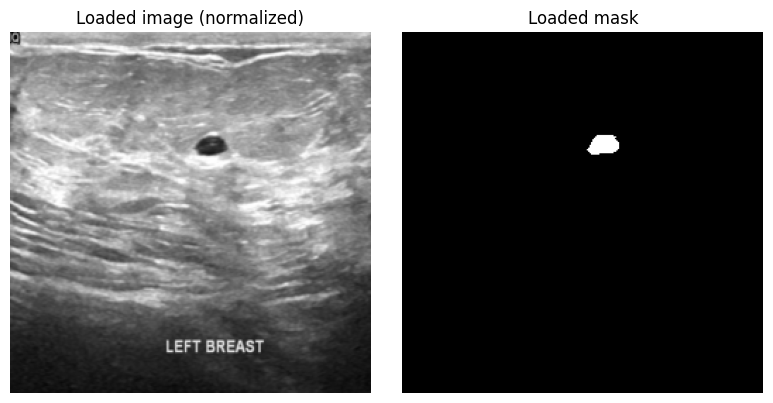

In [15]:
# Load one .npz back and check it looks right
sample = np.load(records[0]['npz_path'])

print(f"Keys in .npz: {list(sample.keys())}")
print(f"Image shape: {sample['image'].shape}")
print(f"Mask shape:  {sample['mask'].shape}")
print(f"Image mean: {sample['image'].mean():.4f}")
print(f"Mask unique values: {np.unique(sample['mask'])}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample['image'], cmap='gray')
axes[0].set_title('Loaded image (normalized)')
axes[0].axis('off')
axes[1].imshow(sample['mask'], cmap='gray')
axes[1].set_title('Loaded mask')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [16]:
from scipy.ndimage import binary_dilation

In [17]:
def create_derived_masks(mask_binary, image_height):
    """
    Takes a binary tumor mask (0s and 1s, shape 256x256)
    and creates all derived region masks.
    """

    # --- 1. Tumor mask (original) ---
    tumor_mask = mask_binary.copy()

    # --- 2. Peritumoral ring 5px ---
    # dilate tumor by 5px, then subtract original tumor
    dilated_5  = binary_dilation(tumor_mask, iterations=5).astype(np.uint8)
    ring_5px   = dilated_5 - tumor_mask

    # --- 3. Peritumoral ring 15px ---
    # dilate by 15px, subtract the 5px dilation
    dilated_15 = binary_dilation(tumor_mask, iterations=15).astype(np.uint8)
    ring_15px  = dilated_15 - dilated_5

    # --- 4. Posterior region ---
    # region below tumor bounding box until bottom of image
    posterior_mask = np.zeros_like(mask_binary)
    if tumor_mask.sum() > 0:
        # find the bottom row of the tumor
        rows = np.where(tumor_mask.sum(axis=1) > 0)[0]
        tumor_bottom_row = rows.max()
        # everything below that row = posterior region
        posterior_mask[tumor_bottom_row+1:, :] = 1

    # --- 5. Skin / superficial region ---
    # top 12% of image height
    skin_mask = np.zeros_like(mask_binary)
    skin_bottom = int(image_height * 0.12)
    skin_mask[:skin_bottom, :] = 1

    # --- 6. Background tissue region ---
    # everything that is NOT tumor, NOT peritumoral rings
    # also exclude skin and posterior for a clean mid-tissue region
    excluded = np.clip(tumor_mask + dilated_15, 0, 1)
    background_mask = (1 - excluded).astype(np.uint8)

    return {
        'tumor_mask'        : tumor_mask,
        'ring_5px'          : ring_5px,
        'ring_15px'         : ring_15px,
        'posterior_mask'    : posterior_mask,
        'skin_mask'         : skin_mask,
        'background_mask'   : background_mask,
    }

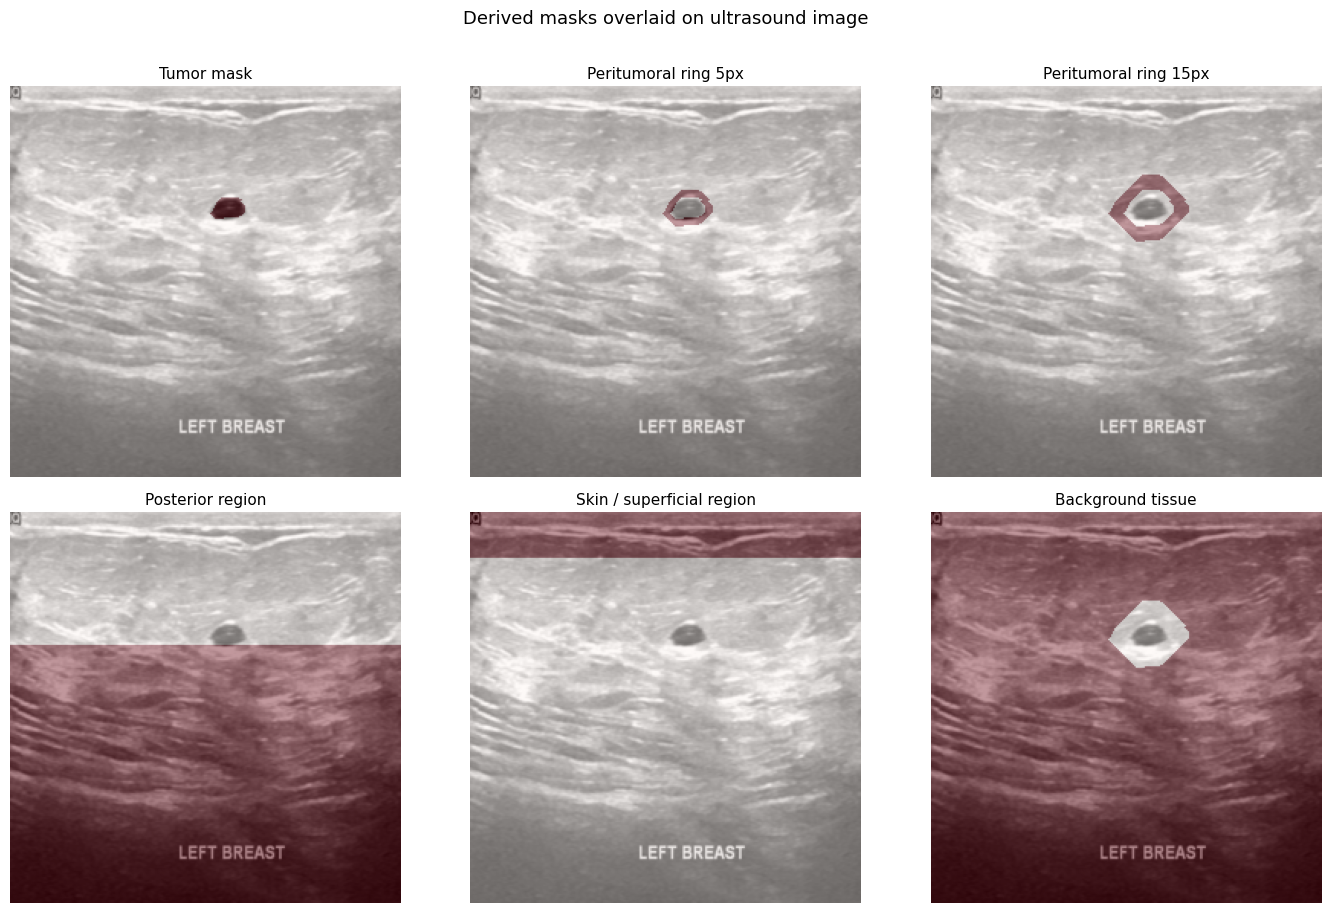

In [18]:
# Use the test image you already loaded earlier
img_proc, mask_proc, orig_mean, orig_std = preprocess_image_and_mask(
    test_img_path, test_mask_path, IMAGE_SIZE
)

masks = create_derived_masks(mask_proc, image_height=IMAGE_SIZE[0])

# Plot all 6 masks
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

titles = [
    'Tumor mask',
    'Peritumoral ring 5px',
    'Peritumoral ring 15px',
    'Posterior region',
    'Skin / superficial region',
    'Background tissue',
]

mask_keys = [
    'tumor_mask',
    'ring_5px',
    'ring_15px',
    'posterior_mask',
    'skin_mask',
    'background_mask',
]

for i, (key, title) in enumerate(zip(mask_keys, titles)):
    # Show the original image underneath in gray, mask overlaid in color
    axes[i].imshow(img_proc, cmap='gray')
    axes[i].imshow(masks[key], cmap='Reds', alpha=0.4)
    axes[i].set_title(title, fontsize=11)
    axes[i].axis('off')

plt.suptitle('Derived masks overlaid on ultrasound image', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# Re-run full dataset with derived masks saved into each .npz

records = []
errors  = []

for label in LABELS:
    folder = DATASET_PATH / label
    images = sorted([f for f in folder.glob("*.png") if '_mask' not in f.name])

    print(f"\nProcessing {label}: {len(images)} images...")

    for img_path in images:
        mask_path = folder / (img_path.stem + '_mask.png')

        if not mask_path.exists():
            errors.append(img_path.name)
            continue

        try:
            img_proc, mask_proc, mean, std = preprocess_image_and_mask(
                img_path, mask_path, IMAGE_SIZE
            )

            masks = create_derived_masks(mask_proc, image_height=IMAGE_SIZE[0])

            save_name = f"{label}_{img_path.stem}.npz"
            save_path = OUTPUT_PATH / save_name

            np.savez_compressed(
                save_path,
                image           = img_proc,
                tumor_mask      = masks['tumor_mask'],
                ring_5px        = masks['ring_5px'],
                ring_15px       = masks['ring_15px'],
                posterior_mask  = masks['posterior_mask'],
                skin_mask       = masks['skin_mask'],
                background_mask = masks['background_mask'],
            )

            records.append({
                'case_id'       : img_path.stem,
                'label'         : label,
                'npz_path'      : str(save_path),
                'orig_mean'     : round(mean, 4),
                'orig_std'      : round(std,  4),
                'tumor_pixels'  : int(masks['tumor_mask'].sum()),
                'ring5_pixels'  : int(masks['ring_5px'].sum()),
                'ring15_pixels' : int(masks['ring_15px'].sum()),
                'posterior_pixels': int(masks['posterior_mask'].sum()),
                'skin_pixels'   : int(masks['skin_mask'].sum()),
                'bg_pixels'     : int(masks['background_mask'].sum()),
            })

        except Exception as e:
            print(f"  ERROR on {img_path.name}: {e}")
            errors.append(img_path.name)

print(f"\nDone! Processed: {len(records)}, Errors: {len(errors)}")


Processing benign: 437 images...

Processing malignant: 210 images...

Processing normal: 133 images...

Done! Processed: 780, Errors: 0


In [20]:
manifest = pd.DataFrame(records)
manifest.to_csv(DATASET_PATH / 'processed_manifest.csv', index=False)
print(manifest['label'].value_counts())
manifest.head()

label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


,case_id,label,npz_path,orig_mean,orig_std,tumor_pixels,ring5_pixels,ring15_pixels,posterior_pixels,skin_pixels,bg_pixels
0,benign (1),benign,C:\Users\jessi\OneDrive\Desktop\aiims2\process...,132.367996,57.481800,246,325,950,43264,7680,64015
1,benign (10),benign,C:\Users\jessi\OneDrive\Desktop\aiims2\process...,103.239700,57.855301,5406,1283,2673,35840,7680,56174
2,benign (100),benign,C:\Users\jessi\OneDrive\Desktop\aiims2\process...,90.110001,67.415604,3040,1023,2330,34816,7680,59143
3,benign (101),benign,C:\Users\jessi\OneDrive\Desktop\aiims2\process...,103.225197,56.699200,1032,606,1481,34560,7680,62417
4,benign (102),benign,C:\Users\jessi\OneDrive\Desktop\aiims2\process...,54.383701,36.973999,3199,994,2280,46336,7680,59063
